In [1]:
import spherical as sp
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import torch
from maps import SkyMap

# Convolutions in the sphere
We follow Krachmalnicoff & Tomasi (A&A, 2019, 628, A129) to define convolutional layers in the sphere using the HEALPix pixelization.

Let us define an HEALPix NSIDE and use the NESTED mapping. We define three layers: a convolutional layer with one input and one output filter, a downsampling layer using average pooling and an upsampling layer that just repeats every pixel.

In [2]:
NSIDE = 32
nest = True

D = 0.007
PHI =  5
THETA = 1
NBAR = 50
truths = [NBAR, D, PHI, THETA]

conv = sp.sphericalConv(NSIDE, 1, 1, nest=nest)
down = sp.sphericalDown(NSIDE)
up = sp.sphericalUp(NSIDE // 2)

Define a simple map on the sphere and apply the different layers.

torch.Size([1, 1, 12288])


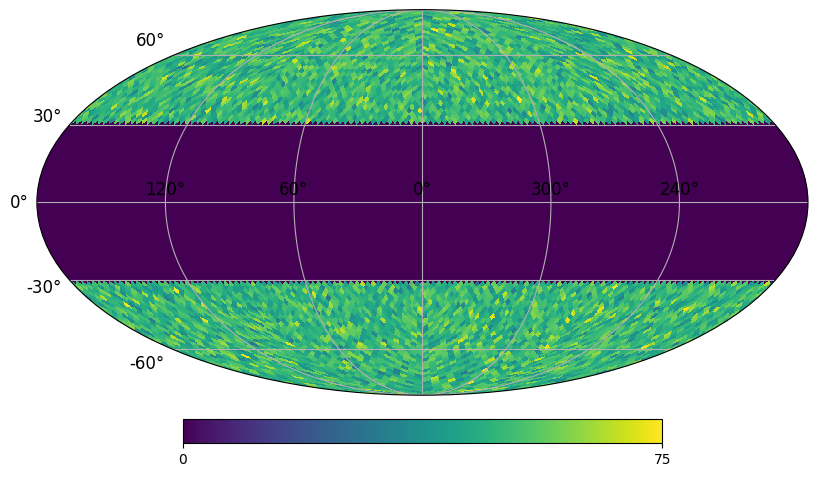

In [15]:
simulation_class = SkyMap()
simulation_class.generate_dipole(torch.as_tensor(truths))
simulation_class.mask_pixels(fill_value=0, equator_mask=30)
hp.projview(
    simulation_class.density_map.numpy(), nest=True, graticule=True,
    graticule_labels=True
)

im = simulation_class.density_map[None, None, :]
print(im.shape)
# im[0, 0, :] = torch.linspace(0.0, 1.0, npix)

## Full Architecture

tensor([[[-53.1717, -53.1563, -53.1083, -53.0634, -37.2382, -37.1299, -36.9740,
          -37.4039, -56.7259, -56.4864, -56.6956, -56.8579]]])


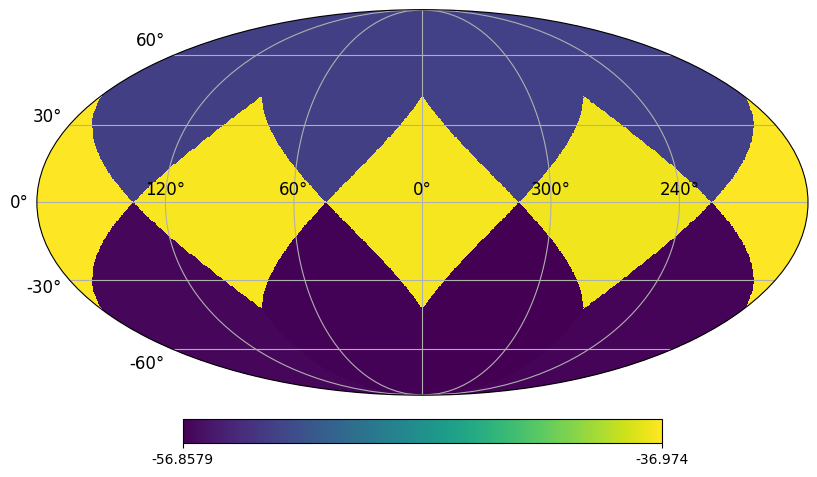

In [37]:
with torch.no_grad():
    # 32 -> 16
    conv = sp.sphericalConv(32, 1, 1, nest=nest)
    down = sp.sphericalDown(32)
    out = conv(im)
    out = down(out)

    # 16 -> 8
    conv = sp.sphericalConv(16, 1, 1, nest=nest)
    down = sp.sphericalDown(16)
    out = conv(out)
    out = down(out)

    # 8 -> 4
    conv = sp.sphericalConv(8, 1, 1, nest=nest)
    down = sp.sphericalDown(8)
    out = conv(out)
    out = down(out)

    # 4 -> 2
    conv = sp.sphericalConv(4, 1, 1, nest=nest)
    down = sp.sphericalDown(4)
    out = conv(out)
    out = down(out)

    # 2 -> 1
    conv = sp.sphericalConv(2, 1, 1, nest=nest)
    down = sp.sphericalDown(1)
    out = conv(out)
    out = down(out)

hp.projview(out[0, 0, :].numpy(), nest=True, graticule=True, graticule_labels=True)
print(out)

Just the convolutional layer:

In [35]:
with torch.no_grad():
    out = conv(im)
out.shape

torch.Size([1, 1, 48])

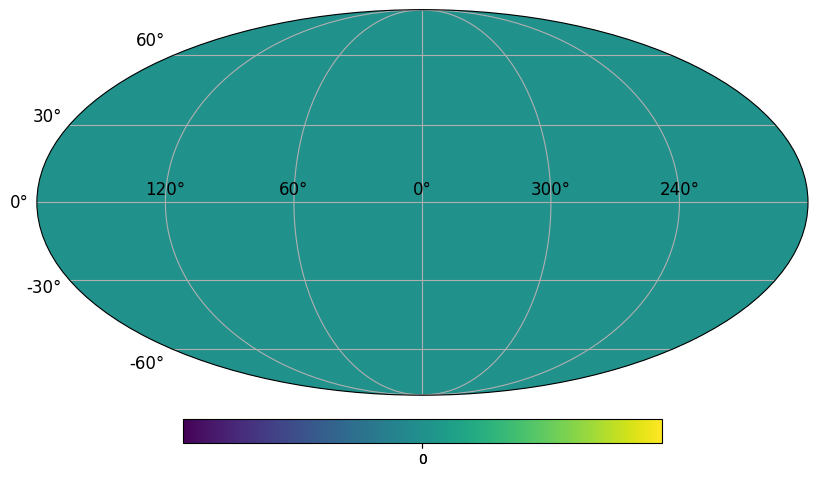

In [36]:
hp.projview(out[0, 0, :].numpy(), nest=True, graticule=True, graticule_labels=True)

Convolution+downsampling:

In [75]:
with torch.no_grad():    
    out = conv(im)
    out = down(out)    

In [ ]:
hp.projview(out[0, 0, :].numpy(), nest=nest, graticule=True, graticule_labels=True)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (736872275.py, line 1)

Convolution+downsampling+upsampling:

In [60]:
with torch.no_grad():    
    out = conv(im)
    out = down(out)    
    out = up(out)

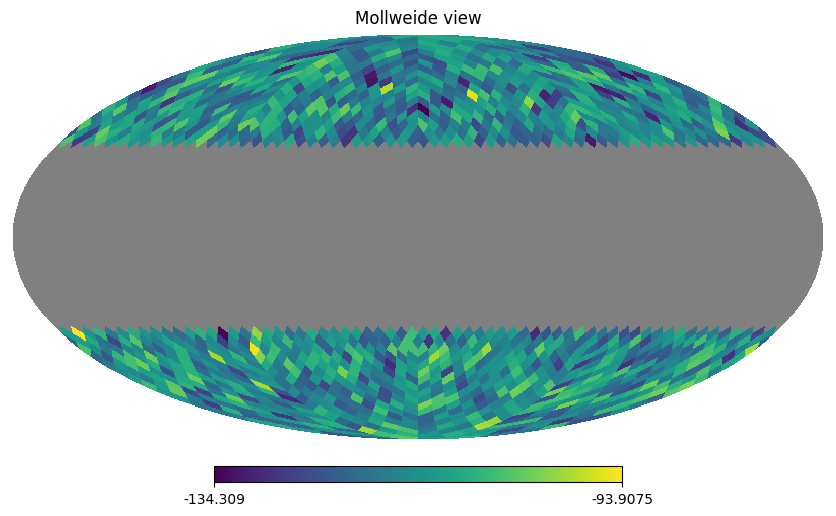

In [61]:
hp.mollview(out[0, 0, :].numpy(), nest=nest)

In [51]:
out.shape

torch.Size([1, 1, 768])